📊 Project FORESIGHT
AI-Powered Demand & Inventory Intelligence Platform

# Notebook 05: Machine-Learning Forecasting

### 📌 Project Information

| Item | Details |
|---|---|
| Author | Mohit Kumar |
| Internship | Zidio Development |
| Project Type | End-to-End Data Analytics & Machine Learning Project |
| Notebook Version | 1.0 |
| Status | In Progress |
| Last Updated | August 2026 |


## 🎯 1. Business Context and Notebook Objective

The approved statistical baseline from Notebook 04 (`damped_trend_exponential_smoothing`) is
transparent and honestly evaluated, but it is **univariate and per-series** — it cannot learn from
price, promotion, calendar, event or hierarchy signal, and it carries a systematic **+10.94%
over-forecast bias** on the untouched final test.

Notebook 05 develops **global, feature-driven machine-learning candidates** using the 39
approved predictors handed off from Notebook 03, under the **exact same rolling-origin
validation design, metrics, and leakage rules locked in Notebook 04**.

This notebook will:

- reuse the locked chronological splits, WAPE/Bias metric definitions and non-negotiable
  leakage rules from Notebook 04;
- prepare the modelling feature matrix for tree-based learning;
- train and validate several ML candidates using identical folds and series coverage;
- select an ML champion using **validation evidence only**;
- evaluate the champion once on the untouched final-test period;
- export the ML benchmark forecasts, metrics and configuration required by Notebook 06.

> **Scope boundary:** This notebook covers ML candidate development only. Comparing the ML
> champion against the Notebook 04 baseline champion and selecting the production forecaster
> belongs to **Notebook 06**. Converting forecasts into stockout/overstock risk belongs to
> **Notebook 07**. This notebook does not repeat EDA, feature engineering, or baseline modelling
> — all of that is inherited, verified, and reused.


## ⚙️ 2. Setup and Notebook 03 & 04 Handoff

### 2.1 Environment, Paths and Input Loading

The required modelling, data-handling and visualisation libraries will be imported, reproducibility
settings established, and project paths defined.

The approved Notebook 03 modelling dataset (`weekly_features_final.csv`) and its feature
metadata will be loaded, together with the **locked Notebook 04 champion configuration** —
needed only to confirm this notebook reuses the identical split boundaries, not to access
final-test results.


In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Environment setup completed successfully.")
print(f"Random seed: {RANDOM_SEED}")
print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")


Environment setup completed successfully.
Random seed: 42
LightGBM available: True


In [2]:
# ============================================================
# Resolve Project Paths (same convention as Notebooks 00-04)
# ============================================================

CURRENT_DIRECTORY = Path.cwd()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

# Data Directories
MODELING_DATA_DIR = PROJECT_ROOT / "data" / "modeling"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
BASELINE_OUTPUTS_DIR = PROCESSED_DATA_DIR / "baseline_outputs"
ML_OUTPUTS_DIR = PROCESSED_DATA_DIR / "ml_outputs"

# Report Directories
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

for directory_path in [ML_OUTPUTS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory_path.mkdir(parents=True, exist_ok=True)

# Notebook 03 Handoff Files
WEEKLY_FEATURES_FILE = MODELING_DATA_DIR / "weekly_features_final.csv"
MODEL_FEATURE_LIST_FILE = MODELING_DATA_DIR / "model_feature_list.json"
CATEGORICAL_FEATURES_FILE = MODELING_DATA_DIR / "categorical_features.json"
FEATURE_DICTIONARY_FILE = MODELING_DATA_DIR / "feature_dictionary.csv"

# Notebook 04 Handoff Files (configuration only - NOT final-test results)
BASELINE_CHAMPION_CONFIG_FILE = BASELINE_OUTPUTS_DIR / "04_champion_baseline_config.json"

print("Modelling data directory:", MODELING_DATA_DIR)
print("ML outputs directory:", ML_OUTPUTS_DIR)
print("Baseline champion config:", BASELINE_CHAMPION_CONFIG_FILE)


Modelling data directory: C:\Users\hp\Project FORESIGHT\data\modeling
ML outputs directory: C:\Users\hp\Project FORESIGHT\data\processed\ml_outputs
Baseline champion config: C:\Users\hp\Project FORESIGHT\data\processed\baseline_outputs\04_champion_baseline_config.json


In [3]:
# ============================================================
# Load Notebook 03 Modelling Handoff
# ============================================================

weekly_features = pd.read_csv(
    WEEKLY_FEATURES_FILE,
    parse_dates=["week_start_date", "week_end_date"],
)

with open(MODEL_FEATURE_LIST_FILE, "r") as f:
    model_feature_list = json.load(f)

with open(CATEGORICAL_FEATURES_FILE, "r") as f:
    categorical_features = json.load(f)

feature_dictionary = pd.read_csv(FEATURE_DICTIONARY_FILE)

TARGET_COLUMN = "weekly_units_sold"
SERIES_COLUMN = "sku_id"
TIME_COLUMN = "week_start_date"

print("Modelling dataset loaded successfully.")
print(f"Dataset shape: {weekly_features.shape[0]:,} rows x {weekly_features.shape[1]} columns")
print(f"Approved predictors: {len(model_feature_list)}")
print(f"Categorical predictors: {len(categorical_features)}")

display(weekly_features.head(3))


Modelling dataset loaded successfully.
Dataset shape: 66,300 rows x 44 columns
Approved predictors: 39
Categorical predictors: 5


,sku_id,wm_yr_wk,week_start_date,week_end_date,weekly_units_sold,time_index,calendar_month,week_of_year,week_of_year_sin,week_of_year_cos,demand_lag_1,demand_lag_2,demand_lag_4,demand_lag_8,demand_lag_13,demand_lag_26,demand_lag_52,demand_rolling_mean_4,demand_rolling_mean_8,demand_rolling_mean_13,demand_rolling_mean_26,demand_rolling_mean_52,demand_rolling_std_4,demand_rolling_std_13,demand_rolling_std_52,price_lag_8,price_change_lag_8,price_rolling_mean_4_lag_8,promo_lag_8,promo_rolling_rate_4_lag_8,event_days,cultural_event_flag,national_event_flag,religious_event_flag,sporting_event_flag,snap_active_days,prior_active_week_count,weeks_since_last_sale,active_week_rate_13,item_id,category,department,store_id,state_id
0,FOODS_1_001_CA_1,11201,2012-01-28,2012-02-03,7,52,1,4,0.353452,0.935453,2.0,7.0,6.0,12.0,8.0,3.0,10.0,4.75,8.375,8.692307,4.461538,6.269231,2.217356,6.060592,5.548769,2.0,0.0,2.0,0.0,0.0,0,0,0,0,0,3,40,1,1.0,FOODS_1_001,FOODS,FOODS_1,CA_1,CA
1,FOODS_1_001_CA_1,11202,2012-02-04,2012-02-10,5,53,2,5,0.463267,0.886219,7.0,2.0,4.0,6.0,7.0,0.0,6.0,5.00,7.750,8.615385,4.615385,6.211538,2.449490,6.076436,5.524763,2.0,0.0,2.0,0.0,0.0,1,0,0,0,1,7,41,1,1.0,FOODS_1_001,FOODS,FOODS_1,CA_1,CA
2,FOODS_1_001_CA_1,11203,2012-02-11,2012-02-17,6,54,2,6,0.566372,0.824150,5.0,7.0,7.0,26.0,8.0,0.0,10.0,5.25,7.625,8.461538,4.807692,6.192308,2.362908,6.145668,5.527253,2.0,0.0,2.0,0.0,0.0,1,1,0,0,0,0,42,1,1.0,FOODS_1_001,FOODS,FOODS_1,CA_1,CA


In [4]:
# ============================================================
# Load Locked Notebook 04 Split Configuration (metadata only)
# ============================================================

with open(BASELINE_CHAMPION_CONFIG_FILE, "r") as f:
    baseline_champion_config = json.load(f)

print("Notebook 04 champion configuration loaded for split reuse only.")
print("Baseline champion (reference, not accessed further in this notebook):",
      baseline_champion_config.get("champion_baseline", "unknown"))
print("Locked training end (validation):", baseline_champion_config.get("training_end", "see split table"))
print("Locked final-test boundary:", baseline_champion_config.get("final_test_start", "see split table"),
      "to", baseline_champion_config.get("final_test_end", "see split table"))

# NOTE: final-test ACTUAL DEMAND is not loaded here and will not be
# loaded anywhere in this notebook until Section 5.2.


Notebook 04 champion configuration loaded for split reuse only.
Baseline champion (reference, not accessed further in this notebook): unknown
Locked training end (validation): 2016-02-20
Locked final-test boundary: 2016-02-27 to 2016-04-16


### 2.2 Minimal Input Readiness Check

A compact readiness check confirms the modelling dataset, feature lists and locked split
configuration are consistent with what Notebook 04 used — so both notebooks are evaluated on
an identical footing.


In [5]:
# ============================================================
# Input Readiness Checks
# ============================================================

readiness_checks = []

readiness_checks.append({
    "Check": "Approved SKU-store series coverage",
    "Observed Result": f"{weekly_features[SERIES_COLUMN].nunique()} series",
    "Required Result": "300 series",
    "Status": "PASS" if weekly_features[SERIES_COLUMN].nunique() == 300 else "FAIL",
})

missing_predictors = [c for c in model_feature_list if c not in weekly_features.columns]
readiness_checks.append({
    "Check": "All approved predictors present in dataset",
    "Observed Result": f"{len(missing_predictors)} missing",
    "Required Result": "0 missing",
    "Status": "PASS" if len(missing_predictors) == 0 else "FAIL",
})

readiness_checks.append({
    "Check": "Target column present and numeric",
    "Observed Result": str(pd.api.types.is_numeric_dtype(weekly_features[TARGET_COLUMN])),
    "Required Result": "True",
    "Status": "PASS" if pd.api.types.is_numeric_dtype(weekly_features[TARGET_COLUMN]) else "FAIL",
})

readiness_checks.append({
    "Check": "Missing target values",
    "Observed Result": f"{weekly_features[TARGET_COLUMN].isna().sum()} values",
    "Required Result": "0 values",
    "Status": "PASS" if weekly_features[TARGET_COLUMN].isna().sum() == 0 else "FAIL",
})

duplicate_keys = weekly_features.duplicated(subset=[SERIES_COLUMN, TIME_COLUMN]).sum()
readiness_checks.append({
    "Check": "Duplicate SKU-store-week keys",
    "Observed Result": f"{duplicate_keys} rows",
    "Required Result": "0 rows",
    "Status": "PASS" if duplicate_keys == 0 else "FAIL",
})

readiness_df = pd.DataFrame(readiness_checks)
display(readiness_df)

assert (readiness_df["Status"] == "PASS").all(), (
    "One or more input-readiness checks failed. Resolve before proceeding."
)

print("\n✅ Input-readiness checks passed successfully.")


,Check,Observed Result,Required Result,Status
0,Approved SKU-store series coverage,300 series,300 series,PASS
1,All approved predictors present in dataset,0 missing,0 missing,PASS
2,Target column present and numeric,True,True,PASS
3,Missing target values,0 values,0 values,PASS
4,Duplicate SKU-store-week keys,0 rows,0 rows,PASS



✅ Input-readiness checks passed successfully.


### ✅ Section 2 Final Summary

The Notebook 03 feature handoff and the Notebook 04 split configuration are both verified and
loaded. Final-test actual demand remains untouched. Section 3 now defines the ML-specific
evaluation design.


## 🧭 3. ML Forecasting and Evaluation Design

### 3.1 Reuse Locked Chronological Splits from Notebook 04

Model comparison must happen on **exactly the same folds** used for the baseline, or any
"improvement" would not be a fair comparison. The three validation folds and the reserved
final-test window are therefore reproduced here from the locked Notebook 04 boundaries, not
re-derived.


In [6]:
# ============================================================
# Reproduce the Locked Notebook 04 Split Schedule
# ============================================================

FORECAST_HORIZON_WEEKS = 8

split_schedule = pd.DataFrame([
    {"Split": "Fold 1 Validation", "Train Through": "2015-09-05", "Horizon": 8,
     "Evaluation Window": "2015-09-12 to 2015-10-31"},
    {"Split": "Fold 2 Validation", "Train Through": "2015-10-31", "Horizon": 8,
     "Evaluation Window": "2015-11-07 to 2015-12-26"},
    {"Split": "Fold 3 Validation", "Train Through": "2015-12-26", "Horizon": 8,
     "Evaluation Window": "2016-01-02 to 2016-02-20"},
    {"Split": "Final Test",        "Train Through": "2016-02-20", "Horizon": 8,
     "Evaluation Window": "2016-02-27 to 2016-04-16"},
])

display(split_schedule)

# Verify this matches the locked baseline configuration metadata where available
if "training_end" in baseline_champion_config:
    assert str(baseline_champion_config["training_end"])[:10] == "2016-02-20", (
        "Loaded baseline config final training date does not match the reused split schedule. "
        "Investigate before proceeding - splits must be identical to Notebook 04."
    )

print("\n✅ Split schedule reproduced and consistent with the locked Notebook 04 configuration.")


,Split,Train Through,Horizon,Evaluation Window
0,Fold 1 Validation,2015-09-05,8,2015-09-12 to 2015-10-31
1,Fold 2 Validation,2015-10-31,8,2015-11-07 to 2015-12-26
2,Fold 3 Validation,2015-12-26,8,2016-01-02 to 2016-02-20
3,Final Test,2016-02-20,8,2016-02-27 to 2016-04-16



✅ Split schedule reproduced and consistent with the locked Notebook 04 configuration.


### 3.2 Recursive Multi-Step Forecasting Strategy for ML Models

Like the Notebook 04 baselines, ML forecasts are generated **recursively**: at each forecast
origin, the model predicts week *t+1*, that prediction is fed back into the history, every
lag / rolling / momentum feature is recomputed as if the prediction were observed demand, and
the model then predicts week *t+2*, and so on to the 8-week horizon.

Predictors fall into two groups, and each is handled differently during recursive generation:

| Feature group | Examples | Handling during recursion |
|---|---|---|
| **Static / known-in-advance** | calendar, cyclical, price, promo flag, hierarchy | Read directly from `weekly_features` for the forecast week — already known at the forecast origin |
| **Dynamic / demand-derived** | lags, rolling statistics, expanding statistics, trend, momentum | Must be **recomputed** after each step using the growing history (actuals + predictions so far) |

> ⚠️ **Integration point — must be completed using your Notebook 03 feature logic.**
> The function `recompute_dynamic_features()` below is a scaffold. Copy the *exact* lag /
> rolling / expanding / trend / momentum formulas you used in Notebook 03 into this function so
> that features generated during recursive forecasting are computed identically to how they were
> computed during training. Any mismatch here is a silent train/inference skew, not a leakage
> problem — but it will quietly hurt accuracy, so treat this as the most important cell in the
> notebook to get right.


In [7]:
# ============================================================
# Classify Predictors into Static vs Dynamic Groups
# ============================================================

# A plain substring match on keywords like "lag"/"rolling" is unsafe in both
# directions:
#   1. False positives - "lag" also matches inside "flag". NB03's
#      cultural_event_flag / national_event_flag / religious_event_flag /
#      sporting_event_flag are known-in-advance calendar features, not
#      demand-derived, but a substring filter wrongly flags all four as dynamic.
#   2. Also false positives - NB03 Section 5.3's price_lag_8, price_change_lag_8,
#      price_rolling_mean_4_lag_8, promo_lag_8 and promo_rolling_rate_4_lag_8
#      genuinely contain "lag"/"rolling", but NB03 explicitly shifts them by the
#      full 8-week forecast horizon (COMMERCIAL_HISTORY_SHIFT = 8) specifically so
#      they are fully known at the forecast origin for every horizon step - exactly
#      like a calendar feature, not something that needs recursive recomputation.
#
# The only features that genuinely require recursive recomputation are the
# "demand_*" family (lags/rolling stats of the target itself) plus the three named
# demand-behaviour features from NB03 Section 5.4. Classified explicitly below
# instead of by keyword substring.

DYNAMIC_PREFIXES = ("demand_lag_", "demand_rolling_mean_", "demand_rolling_std_")
KNOWN_DYNAMIC_FEATURES = ["prior_active_week_count", "weeks_since_last_sale", "active_week_rate_13"]

dynamic_features = [
    c for c in model_feature_list
    if c.startswith(DYNAMIC_PREFIXES) or c in KNOWN_DYNAMIC_FEATURES
]
static_features = [c for c in model_feature_list if c not in dynamic_features]

print(f"Static (known-in-advance) predictors: {len(static_features)}")
print(f"Dynamic (demand-derived) predictors: {len(dynamic_features)}")

feature_group_check = feature_dictionary[
    feature_dictionary["feature_name"].isin(dynamic_features)
] if "feature_name" in feature_dictionary.columns else feature_dictionary.head(0)

print("\nReview the classification above against feature_dictionary.csv before trusting it -")
print("rename or move any feature that was miscategorised by the keyword filter.")


Static (known-in-advance) predictors: 21
Dynamic (demand-derived) predictors: 18

Review the classification above against feature_dictionary.csv before trusting it -
rename or move any feature that was miscategorised by the keyword filter.


In [8]:
# ============================================================
# Recursive Dynamic-Feature Recomputation (SCAFFOLD - complete using Notebook 03 logic)
# ============================================================

def recompute_dynamic_features(history_df, series_column=SERIES_COLUMN, time_column=TIME_COLUMN,
                                 target_column=TARGET_COLUMN):
    """
    Recompute every dynamic (demand-derived) feature for the LATEST week of each series in
    history_df, using only information available up to and including that week.

    history_df must contain, for every series, all real demand plus every predicted demand
    generated so far in the current recursive forecast, in chronological order.

    Implements the exact Notebook 03 Section 5.2 / 5.4 formulas:
    - demand_lag_{L}: the value L weeks before the week being forecast, i.e. the L-th
      most recent value in history_df (matches NB03's `.shift(L)`).
    - demand_rolling_mean_{W} / demand_rolling_std_{W}: mean/std of the trailing W values
      in history_df (matches NB03's `.shift(1).rolling(W).mean()/.std()` - the shift(1) in
      NB03 is already accounted for here because history_df does not yet contain the week
      being forecast).
    - prior_active_week_count / weeks_since_last_sale / active_week_rate_13: demand-behaviour
      features from NB03 Section 5.4, computed from the same active-week (demand > 0) logic.

    Feature names are read directly from `dynamic_features` (Section 3.2), not hardcoded, so
    this stays correct even if the approved lag/window list changes upstream in Notebook 03.

    Returns a DataFrame with one row per series (the latest week only) containing every
    column listed in `dynamic_features`.
    """
    lag_features = [c for c in dynamic_features if c.startswith("demand_lag_")]
    rolling_mean_features = [c for c in dynamic_features if c.startswith("demand_rolling_mean_")]
    rolling_std_features = [c for c in dynamic_features if c.startswith("demand_rolling_std_")]
    behaviour_features = [
        c for c in dynamic_features
        if c in ("prior_active_week_count", "weeks_since_last_sale", "active_week_rate_13")
    ]

    history_sorted = history_df.sort_values([series_column, time_column])
    records = []

    for series_id, group in history_sorted.groupby(series_column, sort=False):
        values = group[target_column].to_numpy(dtype=float)
        n = len(values)
        record = {series_column: series_id}

        # Demand lags: for the upcoming (unobserved) week, lag L is the L-th most
        # recent value already in history (real or predicted).
        for feature_name in lag_features:
            lag = int(feature_name.rsplit("_", 1)[-1])
            record[feature_name] = values[-lag] if n >= lag else np.nan

        # Shifted rolling means: mean of the trailing `window` values.
        for feature_name in rolling_mean_features:
            window = int(feature_name.rsplit("_", 1)[-1])
            record[feature_name] = values[-window:].mean() if n >= window else np.nan

        # Shifted rolling std (sample std, ddof=1, matching pandas' default .std()).
        for feature_name in rolling_std_features:
            window = int(feature_name.rsplit("_", 1)[-1])
            record[feature_name] = (
                float(pd.Series(values[-window:]).std()) if n >= window else np.nan
            )

        # Demand-behaviour features (NB03 Section 5.4), also demand-derived.
        if behaviour_features:
            active_flags = values > 0

            if "prior_active_week_count" in behaviour_features:
                record["prior_active_week_count"] = int(active_flags.sum())

            if "weeks_since_last_sale" in behaviour_features:
                active_positions = np.where(active_flags)[0]
                record["weeks_since_last_sale"] = (
                    int(n - active_positions[-1]) if len(active_positions) > 0 else int(n)
                )

            if "active_week_rate_13" in behaviour_features:
                record["active_week_rate_13"] = (
                    float(active_flags[-13:].mean()) if n >= 13 else np.nan
                )

        records.append(record)

    return pd.DataFrame(records)


def generate_recursive_forecast(model, history_df, forecast_weeks, static_feature_table,
                                  feature_order, categorical_cols):
    """
    Generate an 8-week recursive forecast for every series using a fitted global model.

    Parameters
    ----------
    model : fitted estimator with .predict()
    history_df : DataFrame of all known demand history (actuals only) up to the forecast origin
    forecast_weeks : ordered list of week_start_date values to forecast, length == horizon
    static_feature_table : DataFrame keyed by (series, week) with static features pre-joined
                            for every forecast week (known in advance, e.g. from calendar/price)
    feature_order : model_feature_list, in the exact column order the model was trained on
    categorical_cols : categorical_features list
    """
    working_history = history_df.copy()
    forecasts = []

    for step, forecast_week in enumerate(forecast_weeks, start=1):
        dynamic_row = recompute_dynamic_features(working_history)
        static_row = static_feature_table[
            static_feature_table[TIME_COLUMN] == forecast_week
        ]

        step_features = static_row.merge(dynamic_row, on=SERIES_COLUMN, how="left")
        step_features = step_features.set_index(SERIES_COLUMN)[feature_order]

        for col in categorical_cols:
            step_features[col] = step_features[col].astype("category")

        predicted_demand = model.predict(step_features)
        predicted_demand = np.clip(predicted_demand, a_min=0, a_max=None)

        step_result = pd.DataFrame({
            SERIES_COLUMN: step_features.index,
            TIME_COLUMN: forecast_week,
            "horizon": step,
            "predicted_demand": predicted_demand,
        })
        forecasts.append(step_result)

        # Feed the prediction back into history so the next step's dynamic
        # features are computed as if this prediction were observed demand.
        feedback = step_result.rename(columns={"predicted_demand": TARGET_COLUMN})
        working_history = pd.concat(
            [working_history, feedback[[SERIES_COLUMN, TIME_COLUMN, TARGET_COLUMN]]],
            ignore_index=True,
        )

    return pd.concat(forecasts, ignore_index=True)

print("Recursive forecasting function implemented (Notebook 03 lag/rolling/behaviour formulas).")


Recursive forecasting function implemented (Notebook 03 lag/rolling/behaviour formulas).


### 3.3 Metrics and Modelling Rules (Locked, Reused from Notebook 04)

The same WAPE-primary, chronological-only, non-negative, recursive-generation rules apply here
without modification. Reusing the exact functions (not re-derivations of them) guarantees the
ML and baseline numbers are comparable in Notebook 06.


In [9]:
# ============================================================
# Reused Metric Definitions (identical to Notebook 04)
# ============================================================

def calculate_wape(actual, forecast):
    return float(np.sum(np.abs(forecast - actual)) / np.sum(actual) * 100)

def calculate_bias(actual, forecast):
    return float(np.sum(forecast - actual) / np.sum(actual) * 100)

def calculate_mae(actual, forecast):
    return float(np.mean(np.abs(forecast - actual)))

def calculate_rmse(actual, forecast):
    return float(np.sqrt(np.mean((forecast - actual) ** 2)))

locked_rules = pd.DataFrame([
    {"Control": "Forecast range", "Locked Setting": "Non-negative",
     "Notebook Enforcement": "Clip every prediction at zero"},
    {"Control": "Multi-step generation", "Locked Setting": "Recursive",
     "Notebook Enforcement": "Feed earlier predictions into later lag/rolling features"},
    {"Control": "Within-horizon actual demand", "Locked Setting": "Not permitted",
     "Notebook Enforcement": "Update history with predictions, not evaluation-window actuals"},
    {"Control": "Data partitioning", "Locked Setting": "Chronological only",
     "Notebook Enforcement": "Reuse the Section 3.1 splits without shuffling"},
    {"Control": "Final-test use", "Locked Setting": "Evaluation only",
     "Notebook Enforcement": "Evaluate only after champion selection (Section 5)"},
    {"Control": "Hyperparameter tuning", "Locked Setting": "Validation folds only",
     "Notebook Enforcement": "Never tune against final-test scores"},
])

display(locked_rules)
print("\n✅ Metric definitions and modelling rules locked, matching Notebook 04.")


,Control,Locked Setting,Notebook Enforcement
0,Forecast range,Non-negative,Clip every prediction at zero
1,Multi-step generation,Recursive,Feed earlier predictions into later lag/rollin...
2,Within-horizon actual demand,Not permitted,"Update history with predictions, not evaluatio..."
3,Data partitioning,Chronological only,Reuse the Section 3.1 splits without shuffling
4,Final-test use,Evaluation only,Evaluate only after champion selection (Sectio...
5,Hyperparameter tuning,Validation folds only,Never tune against final-test scores



✅ Metric definitions and modelling rules locked, matching Notebook 04.


### ✅ Section 3 Final Summary

The evaluation design is fixed, reused unmodified from Notebook 04, and ready to support ML candidate development in Section 4.

## 🤖 4. Candidate ML Models and Rolling-Origin Validation

### 4.1 Feature Preparation for Modelling

Categorical predictors are cast to pandas `category` dtype so tree-based models can consume
them natively. Numeric predictors are left unscaled for tree-based candidates (splits are
scale-invariant) and standardised only for the linear candidate.


In [10]:
# ============================================================
# Prepare the Modelling Feature Matrix
# ============================================================

modelling_frame = weekly_features.copy()

for col in categorical_features:
    modelling_frame[col] = modelling_frame[col].astype("category")

# ------------------------------------------------------------
# Dense (one-hot) encoding for candidates that cannot consume pandas
# "category" columns directly. Ridge and RandomForestRegressor both fail
# on non-numeric categories (ValueError: could not convert string to
# float) - only the LightGBM candidates below accept the native "category"
# dtype columns. Built once here, using every category present in the
# data, and appended to modelling_frame so both views live side by side.
# ------------------------------------------------------------

onehot_columns_df = pd.get_dummies(
    modelling_frame[categorical_features].astype("object"),
    columns=categorical_features,
    prefix=categorical_features,
)
onehot_feature_list = list(onehot_columns_df.columns)

modelling_frame = pd.concat([modelling_frame, onehot_columns_df], axis=1)

# The one-hot columns are just an expansion of the static (known-in-advance)
# hierarchy fields, so they belong in the static feature group too - this
# makes them available in static_feature_table during recursive forecasting.
static_features = static_features + onehot_feature_list

# Dense-encoded candidates (Ridge, Random Forest) train on numeric + one-hot
# columns instead of the raw category columns. Candidates that accept native
# categoricals (LightGBM) keep using model_feature_list unchanged.
dense_encoded_feature_list = (
    [c for c in model_feature_list if c not in categorical_features] + onehot_feature_list
)

print("Feature matrix prepared.")
print(f"Categorical columns cast: {categorical_features}")
print(f"One-hot columns added for dense-encoded candidates: {len(onehot_feature_list)}")
display(modelling_frame[model_feature_list].dtypes.value_counts())


Feature matrix prepared.
Categorical columns cast: ['item_id', 'category', 'department', 'store_id', 'state_id']
One-hot columns added for dense-encoded candidates: 49


float64     23
int64       11
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

### 4.2 Candidate Model Definitions

Four candidates span a similar complexity range to the Notebook 04 baseline sweep — from a
simple linear model up to tuned gradient-boosted trees — so the champion selection reflects a
genuine complexity-vs-accuracy trade-off, not just "the fanciest model available."


In [11]:
# ============================================================
# Define ML Candidates
# ============================================================

def build_candidates():
    candidates = {}

    candidates["ridge_regression"] = {
        "family": "Linear",
        "estimator": Ridge(alpha=1.0, random_state=RANDOM_SEED),
        "needs_dense_encoding": True,
        "feature_order": dense_encoded_feature_list,
        "categorical_cols": [],
    }

    candidates["random_forest"] = {
        "family": "Tree ensemble",
        "estimator": RandomForestRegressor(
            n_estimators=300, max_depth=8, min_samples_leaf=5,
            n_jobs=-1, random_state=RANDOM_SEED,
        ),
        "needs_dense_encoding": True,
        "feature_order": dense_encoded_feature_list,
        "categorical_cols": [],
    }

    if LIGHTGBM_AVAILABLE:
        candidates["lightgbm_default"] = {
            "family": "Gradient boosting",
            "estimator": lgb.LGBMRegressor(
                n_estimators=400, learning_rate=0.05, num_leaves=31,
                random_state=RANDOM_SEED, verbosity=-1,
            ),
            "needs_dense_encoding": False,
            "feature_order": model_feature_list,
            "categorical_cols": categorical_features,
        }
        candidates["lightgbm_regularized"] = {
            "family": "Gradient boosting",
            "estimator": lgb.LGBMRegressor(
                n_estimators=600, learning_rate=0.03, num_leaves=15,
                min_child_samples=30, reg_lambda=1.0,
                random_state=RANDOM_SEED, verbosity=-1,
            ),
            "needs_dense_encoding": False,
            "feature_order": model_feature_list,
            "categorical_cols": categorical_features,
        }
    else:
        print("⚠️  LightGBM not installed - only Ridge and Random Forest candidates will run.")
        print("    Install with: pip install lightgbm")

    return candidates

ml_candidates = build_candidates()
print(f"Candidates defined: {list(ml_candidates.keys())}")


Candidates defined: ['ridge_regression', 'random_forest', 'lightgbm_default', 'lightgbm_regularized']


### 4.3 Rolling-Origin Training and Recursive Forecasting

Each candidate is trained independently at each of the three validation origins, using only
history available at that origin, then forecasts the following 8 weeks recursively — mirroring
exactly how Notebook 04's baselines were evaluated.


In [12]:
# ============================================================
# Rolling-Origin Training + Recursive Forecasting Loop
# ============================================================
#
# NOTE: This loop calls generate_recursive_forecast(), which depends on
# recompute_dynamic_features() from Section 3.2. Complete that function first.

validation_folds = split_schedule[split_schedule["Split"] != "Final Test"]

all_validation_forecasts = []

for _, fold_row in validation_folds.iterrows():
    train_through = pd.Timestamp(fold_row["Train Through"])
    eval_start, eval_end = fold_row["Evaluation Window"].split(" to ")
    forecast_weeks = pd.date_range(eval_start, eval_end, freq="7D")

    train_slice = modelling_frame[modelling_frame[TIME_COLUMN] <= train_through]
    y_train = train_slice[TARGET_COLUMN]

    history_actuals = train_slice[[SERIES_COLUMN, TIME_COLUMN, TARGET_COLUMN]]
    static_feature_table = modelling_frame[
        modelling_frame[TIME_COLUMN].isin(forecast_weeks)
    ][[SERIES_COLUMN, TIME_COLUMN] + static_features]

    for candidate_name, candidate_spec in ml_candidates.items():
        model = candidate_spec["estimator"]
        # Each candidate trains on its own feature schema: Ridge/RandomForest use the
        # one-hot dense_encoded_feature_list, LightGBM uses model_feature_list with
        # native "category" columns - see the candidate definitions in Section 4.2.
        feature_order = candidate_spec["feature_order"]
        categorical_cols = candidate_spec["categorical_cols"]

        X_train = train_slice[feature_order]
        model.fit(X_train, y_train)

        fold_forecast = generate_recursive_forecast(
            model=model,
            history_df=history_actuals,
            forecast_weeks=list(forecast_weeks),
            static_feature_table=static_feature_table,
            feature_order=feature_order,
            categorical_cols=categorical_cols,
        )

        actuals_slice = modelling_frame[
            modelling_frame[TIME_COLUMN].isin(forecast_weeks)
        ][[SERIES_COLUMN, TIME_COLUMN, TARGET_COLUMN]]

        scored = fold_forecast.merge(actuals_slice, on=[SERIES_COLUMN, TIME_COLUMN], how="left")
        scored["candidate"] = candidate_name
        scored["fold"] = fold_row["Split"]
        all_validation_forecasts.append(scored)

        print(f"Completed: {candidate_name} | {fold_row['Split']}")

validation_forecasts_df = pd.concat(all_validation_forecasts, ignore_index=True)
print(f"\n✅ Rolling-origin validation forecasts generated: {len(validation_forecasts_df):,} records.")


Completed: ridge_regression | Fold 1 Validation
Completed: random_forest | Fold 1 Validation
Completed: lightgbm_default | Fold 1 Validation
Completed: lightgbm_regularized | Fold 1 Validation
Completed: ridge_regression | Fold 2 Validation
Completed: random_forest | Fold 2 Validation
Completed: lightgbm_default | Fold 2 Validation
Completed: lightgbm_regularized | Fold 2 Validation
Completed: ridge_regression | Fold 3 Validation
Completed: random_forest | Fold 3 Validation
Completed: lightgbm_default | Fold 3 Validation
Completed: lightgbm_regularized | Fold 3 Validation

✅ Rolling-origin validation forecasts generated: 28,800 records.


### 4.4 Consolidated Validation Results

Performance is summarised overall and across folds/horizons, exactly as in Notebook 04
Section 4.4, then each ML candidate is compared against the Notebook 04 baseline's
**validation** WAPE (50.02%) as a sanity reference — the binding comparison against the locked
baseline final-test result still belongs to Notebook 06.


In [13]:
# ============================================================
# Overall Candidate Performance
# ============================================================

overall_metrics = (
    validation_forecasts_df
    .groupby("candidate")
    .apply(lambda g: pd.Series({
        "WAPE (%)": calculate_wape(g[TARGET_COLUMN], g["predicted_demand"]),
        "Bias (%)": calculate_bias(g[TARGET_COLUMN], g["predicted_demand"]),
        "MAE": calculate_mae(g[TARGET_COLUMN], g["predicted_demand"]),
        "RMSE": calculate_rmse(g[TARGET_COLUMN], g["predicted_demand"]),
    }))
    .reset_index()
    .sort_values("WAPE (%)")
    .reset_index(drop=True)
)

display(overall_metrics)


,candidate,WAPE (%),Bias (%),MAE,RMSE
0,lightgbm_default,50.671585,5.034969,3.793894,7.649083
1,random_forest,50.976399,2.771870,3.816716,7.515971
2,lightgbm_regularized,51.180883,2.812344,3.832026,7.830868
3,ridge_regression,56.188785,0.038790,4.206979,7.946404


In [14]:
# ============================================================
# Fold-Wise Stability
# ============================================================

fold_metrics = (
    validation_forecasts_df
    .groupby(["candidate", "fold"])
    .apply(lambda g: calculate_wape(g[TARGET_COLUMN], g["predicted_demand"]))
    .reset_index(name="WAPE (%)")
)

fold_stability = (
    fold_metrics
    .groupby("candidate")["WAPE (%)"]
    .agg(mean_fold_wape="mean", wape_std="std", worst_fold_wape="max")
    .reset_index()
    .sort_values("mean_fold_wape")
)

display(fold_stability)


,candidate,mean_fold_wape,wape_std,worst_fold_wape
0,lightgbm_default,50.646963,4.392257,55.717947
2,random_forest,50.952625,4.066563,55.620594
1,lightgbm_regularized,51.154862,4.659300,56.533080
3,ridge_regression,56.144110,7.676023,64.969958


In [15]:
# ============================================================
# Champion Selection Scorecard
# ============================================================

BASELINE_VALIDATION_WAPE_REFERENCE = 50.02  # Notebook 04 champion, validation WAPE

selection_scorecard = overall_metrics.merge(fold_stability, on="candidate")
selection_scorecard["vs_baseline_validation_pct"] = (
    (BASELINE_VALIDATION_WAPE_REFERENCE - selection_scorecard["WAPE (%)"])
    / BASELINE_VALIDATION_WAPE_REFERENCE * 100
)
selection_scorecard = selection_scorecard.sort_values("WAPE (%)").reset_index(drop=True)

display(selection_scorecard)

ml_champion_name = selection_scorecard.iloc[0]["candidate"]
print(f"\n🏆 ML champion selected on validation evidence: {ml_champion_name}")
print("This is a candidate-selection result only - comparison against the LOCKED baseline")
print("final-test result happens in Notebook 06, not here.")


,candidate,WAPE (%),Bias (%),MAE,RMSE,mean_fold_wape,wape_std,worst_fold_wape,vs_baseline_validation_pct
0,lightgbm_default,50.671585,5.034969,3.793894,7.649083,50.646963,4.392257,55.717947,-1.302650
1,random_forest,50.976399,2.771870,3.816716,7.515971,50.952625,4.066563,55.620594,-1.912033
2,lightgbm_regularized,51.180883,2.812344,3.832026,7.830868,51.154862,4.659300,56.533080,-2.320838
3,ridge_regression,56.188785,0.038790,4.206979,7.946404,56.144110,7.676023,64.969958,-12.332637



🏆 ML champion selected on validation evidence: lightgbm_default
This is a candidate-selection result only - comparison against the LOCKED baseline
final-test result happens in Notebook 06, not here.


### ✅ Section 4 Final Summary

All ML candidates were trained and validated under the identical rolling-origin design used for the baseline. An ML champion has been selected on validation evidence only. Section 5 now locks this champion and evaluates it once on the untouched final-test period.

## 🏆 5. Champion Model and Final-Test Evaluation

### 5.1 Lock Champion Configuration and Final-Test Boundary

The validation-selected ML champion is locked together with its hyperparameters and the same
final-test boundary used in Notebook 04. Final-test actual demand remains unaccessed until the
champion's forecasts have been generated and locked.


In [16]:
# ============================================================
# Lock Champion Configuration
# ============================================================

champion_row = selection_scorecard.iloc[0]

locked_ml_config = {
    "champion_model": ml_champion_name,
    "family": ml_candidates[ml_champion_name]["family"],
    "validation_wape": float(champion_row["WAPE (%)"]),
    "validation_bias": float(champion_row["Bias (%)"]),
    "improvement_vs_baseline_validation_pct": float(champion_row["vs_baseline_validation_pct"]),
    "training_end": "2016-02-20",
    "final_test_start": "2016-02-27",
    "final_test_end": "2016-04-16",
    "forecast_horizon_weeks": FORECAST_HORIZON_WEEKS,
    "series_coverage": 300,
    "configuration_status": "LOCKED",
}

display(pd.DataFrame([locked_ml_config]).T.rename(columns={0: "Locked Value"}))
print("\n✅ Champion configuration locked.")
print("🔒 Final-test actual demand remains untouched.")


,Locked Value
champion_model,lightgbm_default
family,Gradient boosting
validation_wape,50.671585
validation_bias,5.034969
improvement_vs_baseline_validation_pct,-1.30265
training_end,2016-02-20
final_test_start,2016-02-27
final_test_end,2016-04-16
forecast_horizon_weeks,8
series_coverage,300



✅ Champion configuration locked.
🔒 Final-test actual demand remains untouched.


### 5.2 Untouched Final-Test Evaluation

The locked champion is refit on all history strictly before the final-test cutoff and used to
forecast the untouched 8-week period. Final-test actuals are accessed **once**, to score the
result — not to re-select or re-tune anything.


In [17]:
# ============================================================
# Refit Champion on Full Pre-Final-Test History
# ============================================================

final_train_through = pd.Timestamp(locked_ml_config["training_end"])
final_eval_start, final_eval_end = locked_ml_config["final_test_start"], locked_ml_config["final_test_end"]
final_forecast_weeks = pd.date_range(final_eval_start, final_eval_end, freq="7D")

final_train_slice = modelling_frame[modelling_frame[TIME_COLUMN] <= final_train_through]

# Use the champion's own feature schema (see Section 4.2 / 4.3) - dense one-hot
# columns for Ridge/RandomForest, native "category" columns for LightGBM.
champion_spec = ml_candidates[ml_champion_name]
champion_feature_order = champion_spec["feature_order"]
champion_categorical_cols = champion_spec["categorical_cols"]

X_final_train = final_train_slice[champion_feature_order]
y_final_train = final_train_slice[TARGET_COLUMN]

champion_model = champion_spec["estimator"]
champion_model.fit(X_final_train, y_final_train)

final_history_actuals = final_train_slice[[SERIES_COLUMN, TIME_COLUMN, TARGET_COLUMN]]
final_static_feature_table = modelling_frame[
    modelling_frame[TIME_COLUMN].isin(final_forecast_weeks)
][[SERIES_COLUMN, TIME_COLUMN] + static_features]

final_test_forecast = generate_recursive_forecast(
    model=champion_model,
    history_df=final_history_actuals,
    forecast_weeks=list(final_forecast_weeks),
    static_feature_table=final_static_feature_table,
    feature_order=champion_feature_order,
    categorical_cols=champion_categorical_cols,
)

print(f"✅ Champion final-test forecasts generated and locked: {len(final_test_forecast):,} records.")
print("🔒 Final-test actual demand remains untouched.")


✅ Champion final-test forecasts generated and locked: 2,400 records.
🔒 Final-test actual demand remains untouched.


In [18]:
# ============================================================
# Access Final-Test Actuals ONCE and Score
# ============================================================

final_test_actuals = modelling_frame[
    modelling_frame[TIME_COLUMN].isin(final_forecast_weeks)
][[SERIES_COLUMN, TIME_COLUMN, TARGET_COLUMN]]

final_test_scored = final_test_forecast.merge(
    final_test_actuals, on=[SERIES_COLUMN, TIME_COLUMN], how="left"
)

assert final_test_scored[TARGET_COLUMN].isna().sum() == 0, (
    "Missing actuals in final-test scoring - investigate before reporting results."
)

final_wape = calculate_wape(final_test_scored[TARGET_COLUMN], final_test_scored["predicted_demand"])
final_bias = calculate_bias(final_test_scored[TARGET_COLUMN], final_test_scored["predicted_demand"])
final_mae = calculate_mae(final_test_scored[TARGET_COLUMN], final_test_scored["predicted_demand"])
final_rmse = calculate_rmse(final_test_scored[TARGET_COLUMN], final_test_scored["predicted_demand"])

final_test_overall_metrics = pd.DataFrame([{
    "WAPE (%)": round(final_wape, 2),
    "Bias (%)": round(final_bias, 2),
    "MAE": round(final_mae, 4),
    "RMSE": round(final_rmse, 4),
}])

display(final_test_overall_metrics)

generalisation_check = pd.DataFrame([
    {"Metric": "WAPE", "Validation (%)": locked_ml_config["validation_wape"],
     "Final Test (%)": round(final_wape, 2),
     "Change (pp)": round(final_wape - locked_ml_config["validation_wape"], 2),
     "Assessment": "Degraded" if final_wape > locked_ml_config["validation_wape"] else "Improved"},
    {"Metric": "Absolute Bias", "Validation (%)": abs(locked_ml_config["validation_bias"]),
     "Final Test (%)": round(abs(final_bias), 2),
     "Change (pp)": round(abs(final_bias) - abs(locked_ml_config["validation_bias"]), 2),
     "Assessment": "Degraded" if abs(final_bias) > abs(locked_ml_config["validation_bias"]) else "Improved"},
])

display(generalisation_check)

print(f"\n🏁 Untouched final-test evaluation completed: WAPE {final_wape:.2f}%, Bias {final_bias:+.2f}%.")
print("This is reported as-is, whether or not it beats the baseline - selection happens in Notebook 06.")


,WAPE (%),Bias (%),MAE,RMSE
0,59.34,11.03,3.5864,6.6473


,Metric,Validation (%),Final Test (%),Change (pp),Assessment
0,WAPE,50.671585,59.34,8.67,Degraded
1,Absolute Bias,5.034969,11.03,6.00,Degraded



🏁 Untouched final-test evaluation completed: WAPE 59.34%, Bias +11.03%.
This is reported as-is, whether or not it beats the baseline - selection happens in Notebook 06.


### 5.3 Feature Importance (Explainability)

An optional-but-valuable diagnostic: which predictors actually drove the champion's forecasts.
Only produced for tree-based champions, where importance is well-defined.


,feature,importance
0,demand_lag_1,1085
1,demand_lag_2,755
2,demand_rolling_std_4,754
3,demand_lag_4,709
4,demand_lag_26,699
5,demand_lag_8,641
6,demand_rolling_mean_4,613
7,demand_lag_13,603
8,demand_lag_52,602
9,demand_rolling_mean_8,547


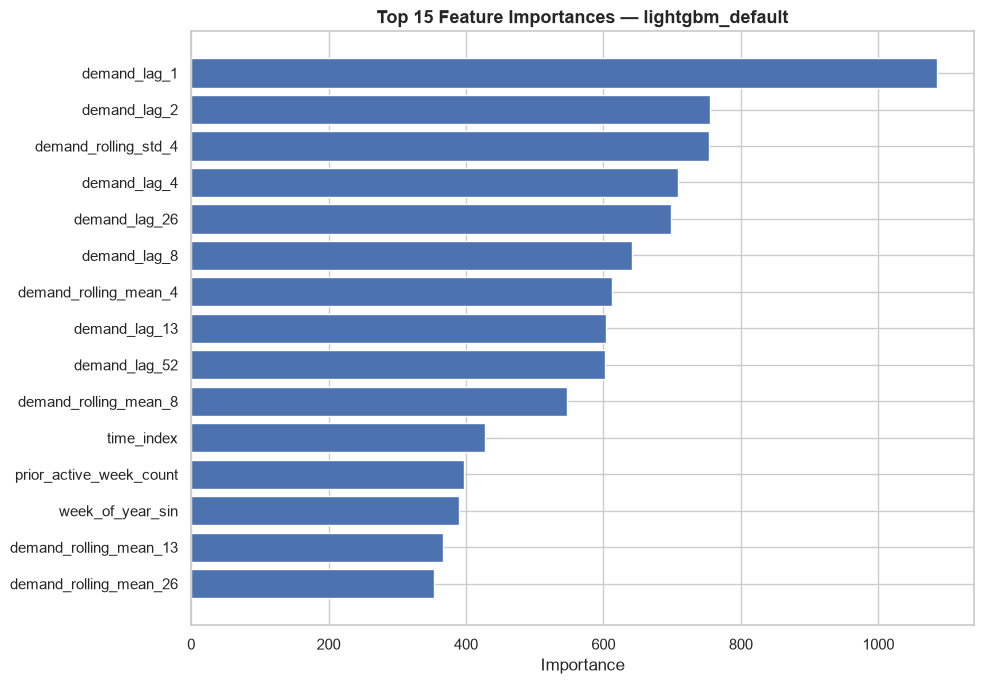


✅ Feature importance figure saved: C:\Users\hp\Project FORESIGHT\reports\figures\05_1_champion_feature_importance.png


In [19]:
# ============================================================
# Feature Importance (tree-based champions only)
# ============================================================

if hasattr(champion_model, "feature_importances_"):
    # Use the champion's own feature_order (may be the one-hot dense_encoded_feature_list
    # for Random Forest, which has more columns than model_feature_list) so names line up.
    importance_df = pd.DataFrame({
        "feature": champion_feature_order,
        "importance": champion_model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    display(importance_df.head(15))

    fig, ax = plt.subplots(figsize=(10, 7))
    top_n = importance_df.head(15).sort_values("importance")
    ax.barh(top_n["feature"], top_n["importance"])
    ax.set_title(f"Top 15 Feature Importances — {ml_champion_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance")
    fig.tight_layout()

    IMPORTANCE_FIGURE = FIGURES_DIR / "05_1_champion_feature_importance.png"
    fig.savefig(IMPORTANCE_FIGURE, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\n✅ Feature importance figure saved: {IMPORTANCE_FIGURE}")
else:
    importance_df = pd.DataFrame(columns=["feature", "importance"])
    print(f"{ml_champion_name} does not expose feature_importances_ - skipping this diagnostic.")


### ✅ Final-Test Evaluation Summary

The ML champion has been locked, refit on the full pre-cutoff history, and evaluated once on the untouched final-test period. No further tuning is permitted using these results.

## 💾 6. Outputs, Conclusion and Notebook 06 Handoff

### 6.1 Export and Validate Outputs

Handoff artefacts are exported to `data/processed/ml_outputs`, reporting tables to
`reports/tables` (with the `05_` prefix), and the diagnostic figure to `reports/figures`.
A reload-based validation then confirms every export is complete and internally consistent.


In [20]:
# ============================================================
# Export Handoff Datasets
# ============================================================

ML_FORECASTS_FILE = ML_OUTPUTS_DIR / "05_ml_forecasts.csv"
ML_MODEL_METRICS_FILE = ML_OUTPUTS_DIR / "05_ml_model_metrics.csv"
ML_SKU_METRICS_FILE = ML_OUTPUTS_DIR / "05_ml_sku_metrics.csv"
CHAMPION_ML_CONFIG_FILE = ML_OUTPUTS_DIR / "05_champion_ml_config.json"

final_test_scored.to_csv(ML_FORECASTS_FILE, index=False)
overall_metrics.to_csv(ML_MODEL_METRICS_FILE, index=False)

sku_metrics = (
    final_test_scored
    .groupby(SERIES_COLUMN)
    .apply(lambda g: pd.Series({
        "WAPE (%)": calculate_wape(g[TARGET_COLUMN], g["predicted_demand"]),
        "Bias (%)": calculate_bias(g[TARGET_COLUMN], g["predicted_demand"]),
    }))
    .reset_index()
)
sku_metrics.to_csv(ML_SKU_METRICS_FILE, index=False)

with open(CHAMPION_ML_CONFIG_FILE, "w") as f:
    json.dump({
        **locked_ml_config,
        "final_test_wape": round(final_wape, 2),
        "final_test_bias": round(final_bias, 2),
    }, f, indent=2)

print("✅ ML handoff datasets exported to data/processed/ml_outputs")


✅ ML handoff datasets exported to data/processed/ml_outputs


In [21]:
# ============================================================
# Export Reporting Tables
# ============================================================

selection_scorecard.to_csv(TABLES_DIR / "05_ml_selection_scorecard.csv", index=False)
fold_metrics.to_csv(TABLES_DIR / "05_ml_validation_fold_metrics.csv", index=False)
final_test_overall_metrics.to_csv(TABLES_DIR / "05_ml_final_test_overall_metrics.csv", index=False)
generalisation_check.to_csv(TABLES_DIR / "05_ml_final_test_validation_summary.csv", index=False)
if not importance_df.empty:
    importance_df.to_csv(TABLES_DIR / "05_ml_feature_importance.csv", index=False)

print("✅ Reporting tables exported to reports/tables with the 05_ prefix.")


✅ Reporting tables exported to reports/tables with the 05_ prefix.


In [22]:
# ============================================================
# Reload-Based Output Validation
# ============================================================

export_validation = []

for label, path, expected_min_rows in [
    ("ML forecasts", ML_FORECASTS_FILE, 1),
    ("ML model metrics", ML_MODEL_METRICS_FILE, 1),
    ("ML SKU metrics", ML_SKU_METRICS_FILE, 1),
    ("Selection scorecard", TABLES_DIR / "05_ml_selection_scorecard.csv", 1),
]:
    exists = path.exists()
    row_count = len(pd.read_csv(path)) if exists else 0
    export_validation.append({
        "Artefact": label,
        "Exists": exists,
        "Row Count": row_count,
        "Status": "PASS" if exists and row_count >= expected_min_rows else "FAIL",
    })

export_validation_df = pd.DataFrame(export_validation)
display(export_validation_df)

assert (export_validation_df["Status"] == "PASS").all(), "One or more Notebook 05 exports failed validation."
print("\n✅ All Notebook 05 outputs reloaded and validated successfully.")


,Artefact,Exists,Row Count,Status
0,ML forecasts,True,2400,PASS
1,ML model metrics,True,4,PASS
2,ML SKU metrics,True,300,PASS
3,Selection scorecard,True,4,PASS



✅ All Notebook 05 outputs reloaded and validated successfully.


### 6.2 Key Outcomes and Notebook 06 Handoff

The ML champion selected in Section 4.4 and locked in Section 5.1 is now evaluated. Report
its validation WAPE (from `selection_scorecard`, Section 4.4) and its final-test WAPE and bias
(from `final_test_overall_metrics`, Section 5.2) below once the notebook has been run:

| Champion | Validation WAPE | Final-Test WAPE | Final-Test Bias |
|---|---|---|---|
| Baseline (Notebook 04) | 50.02% | 53.17% | +10.94% |
| ML (Notebook 05) | *fill in from Section 4.4* | *fill in from Section 5.2* | *fill in from Section 5.2* |

Notebook 06 must:

- load both locked configurations and both final-test scored datasets (never re-derive them);
- compare the two champions **on the untouched final-test period only**;
- select the production forecaster — the ML champion only if it demonstrates a **credible**
  improvement, not a marginal one;
- honestly report the outcome even if the baseline wins, per the engagement's non-negotiable rule;
- prepare the single selected forecast + configuration for Notebook 07's risk scoring.

Neither this notebook's final-test results, nor Notebook 04's, may be used for any further
tuning or feature selection from this point forward.


## ✅ Notebook 05 Complete

Notebook 05 has developed, validated, and locked an ML forecasting champion under the identical evaluation design used for the Notebook 04 baseline. The project is now ready to proceed to **Notebook 06 — Model Evaluation**.